# How to calculate the spatial gradient of a scalar field in cartesian coordiantes

FELiCS can be used to calculate the spatial gradient of a quantity with a few commands. Here, the following cases are described:
- cartesian coordinates: square 2D domain
- cartesian coordinates with spectral dimension: the de-facto 2D domain can be imagined as a 3D channel, which is periodically expanded in the third direction

### Cartesian coordinates on a 2D domain
Here, the gradient of a scalar field on a square 2D mesh is computed. We define our scalar field as follows:
$$\phi(x,y) = \sin(2\pi x)\cos(2\pi y)$$


**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

# create a scalar space
scalarSpace = createFunctionSpace(mesh, order=2, dim=1)

# create a Field object and import the data from the h5 file
phi = Field(scalarSpace, mesh=mesh) 
phi.importH5("function_values_sine")


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/home/knechtel/miniconda3/envs/felics2025_dolfin9/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


**Step 2: Get gradient as a vector field and extract the scalar fields**

We now want to calculate the gradient of our scalar quantity using the `getGradientField()` method of our Field class. This method returns a Field object, which represents a vector-field as we calculate the gradient of a scalar with respect to our two spatial and one spectral dimension. The gradient is defined as
$$\nabla \phi = \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}\right)\ .$$
So for our function the analytical gradient is
$$\nabla \phi = \begin{pmatrix}
2\pi \cos(2\pi x) \cos(2\pi y) \\
-2\pi \sin(2\pi x) \sin(2\pi y) 
\end{pmatrix}\ .$$ 
The resulting field is defined on a vector space with 2 dimension. We can also transform it in two scalar fields via the command 'getListOfSingleFields()'.

In [2]:
gradPhi = phi.getGradientField() # this is a vector field

# get scalar fields from gradient:
gradList = gradPhi.getListOfSingleFields()
phi_x    = gradList[0]
phi_y    = gradList[1]

Now, we verify our solution with the analytically obtained gradient:

In [3]:
# create a vector field
vectorSpace = createFunctionSpace(mesh, order=2, dim=2)
gradPhiSol = Field(vectorSpace, mesh=mesh)
gradPhiSol.importH5("grad_solution")
print("Error: ", sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

Error:  (-0.1487525173092487+0j)


**Step 3: Postprocessing**

Visualization of the gradients by using the FELiCS plotting function:

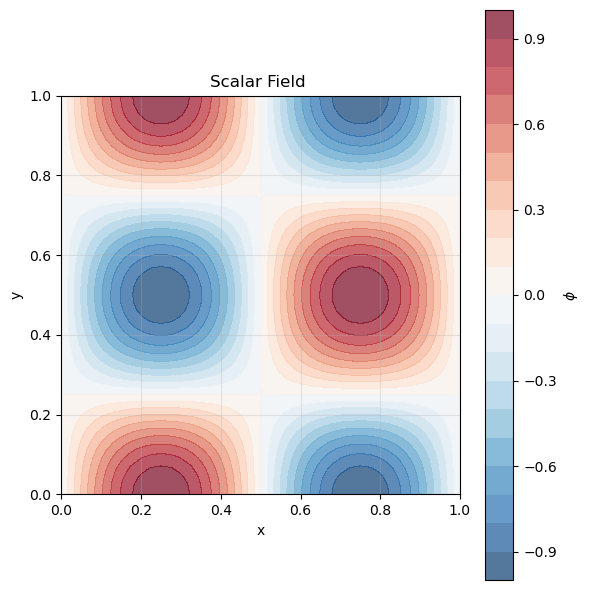

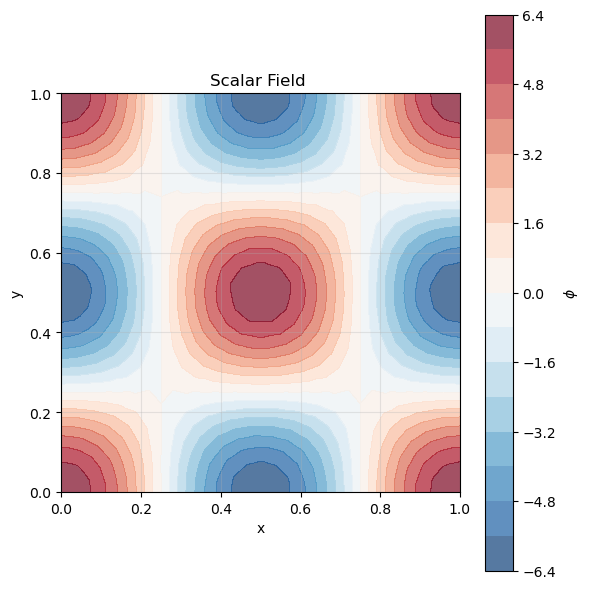

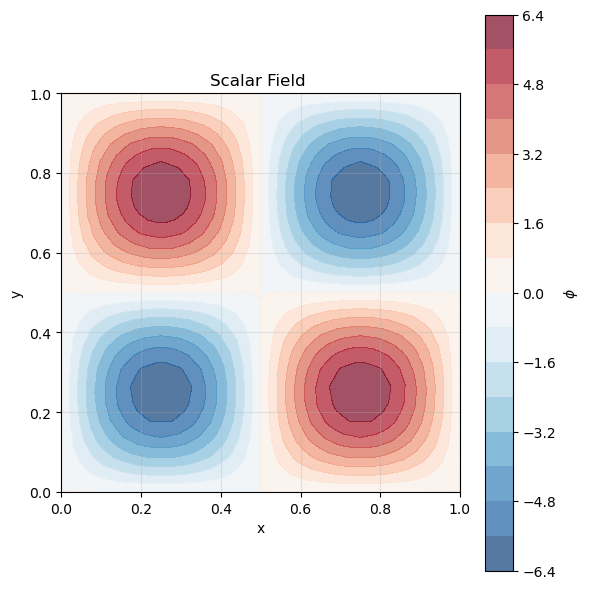

In [7]:
phi.plot()
phi_x.plot()
phi_y.plot()

### Cartesian coordinates with spectral dimension
Here, to the two spatial dimensions (x and y) a third spectral dimension in z-direction is added.
With the spectral dimension the scalar field becomes
$$\phi \cdot e^{imz}$$
where m is the wave number. With the wave number we represent a periodicity of the flow in z-direction, while still only calculating a 2D flowfield.

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

In [8]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"
m = 3

# create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

# create a scalar space
scalarSpace = createFunctionSpace(mesh, order=2, dim=1)

# create a Field object and import the data from the h5 file
phi = Field(scalarSpace, mesh=mesh, m = m) # by setting m to an integer number, the spectral direction is added
phi.importH5("function_values_sine")


Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


**Step 2: Define the gradient Expression and evaluate it on the Field**

With the spectral dimension, the gradient is now 3-dimensional:
$$\nabla \phi = \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}, \frac{\partial \phi}{\partial z}\right)$$
and it is defined as:
$$\nabla \phi = \begin{pmatrix}
2\pi \cos(2\pi x) \cos(2\pi y) \cdot e^{imz} \\
-2\pi \sin(2\pi x) \sin(2\pi y) \cdot e^{imz} \\
im \sin(2\pi x) \cos(2\pi y) \cdot e^{imz}
\end{pmatrix}\ .$$
Note that the derivative in the spectral dimension is imaginary. 
The obtained gradient is a 3-dimemsional vector field:

In [9]:
gradPhi = phi.getGradientField() # this is a vector field

# get scalar fields from gradient:
gradList = gradPhi.getListOfSingleFields()
phi_x    = gradList[0]
phi_y    = gradList[1]
phi_z    = gradList[2]

Again, we verify our solution with the analytically obtained gradient:

In [10]:
vectorSpace = createFunctionSpace(mesh, order=2, dim=3)
gradPhiSol = Field(vectorSpace, mesh=mesh)
gradPhiSol.importH5("grad_solution_cylSpectral_m=3")
print("Error: ", sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

Error:  (-0.1487525173046649+122.2323556236335j)


**TODO: remove this part after validation is done**

In [11]:
import numpy as np

gradPhi = phi.getGradientField()

# Calculate analytical solution
def test_function_2(x):
    """Sine wave function: f(x,y) = sin(2*pi*x) * cos(2*pi*y)"""
    return np.sin(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])

def dtest_dx(x):
    """Derivative of the sine wave function with respect to x: df/dx = 2*pi*cos(2*pi*x)*cos(2*pi*y)"""
    return 2 * np.pi * np.cos(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])

def dtest_dy(x):
    """Derivative of the sine wave function with respect to y: df/dy = -2*pi*sin(2*pi*x)*sin(2*pi*y)"""
    return -2 * np.pi * np.sin(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])

# Calculate function values at DOF coordinates
dof_coordinates = vectorSpace.tabulate_dof_coordinates()

function_values_1 = np.zeros(len(dof_coordinates))
function_values_2 = np.zeros(len(dof_coordinates))

for i, coord in enumerate(dof_coordinates):
    function_values_1[i] = dtest_dx(coord)
    function_values_2[i] = dtest_dy(coord)


print(sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

(-0.1487525173046649+122.2323556236335j)
